## **INSTALL & IMPORT LIBRARY**


Mengimpor semua library seperti: pandas & numpy untuk manipulasi data, matplotlib & seaborn untuk visualisasi, dan sklearn untuk preprocessing, modeling (K-Means, Logistic Regression, Naïve Bayes), serta evaluasi model.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

## **DATA UNDERSTANDING**

Dimulai dengan memeriksa struktur data, nilai yang hilang, dan statistik ringkasan.

Membaca dataset Wine Quality (format CSV) ke dalam DataFrame, lalu menampilkan dimensi data dan 5 baris pertama untuk melihat struktur awal dataset.

In [3]:
df = pd.read_csv('winequality-red.csv')

print("Dimensi data:", df.shape)
print("\nLima baris pertama data:")
df.head()

Dimensi data: (1599, 12)

Lima baris pertama data:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Melakukan 4 pengecekan:
- df.info() → tipe data tiap kolom
- df.describe() → statistik deskriptif (min, max, mean, std)
- isnull().sum() → mendeteksi nilai kosong/hilang
- duplicated().sum() → menghitung baris duplikat

In [4]:
print("Info Dataset:")
display(df.info())

print("\nStatistik Deskriptif:")
display(df.describe())

print("\nJumlah Missing Values per Kolom:")
print(df.isnull().sum())

print(f'JUMLAH DATA YANG TERDUPLIKASI {df.duplicated().sum()}')

Info Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


None


Statistik Deskriptif:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000



Jumlah Missing Values per Kolom:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64
JUMLAH DATA YANG TERDUPLIKASI 240


Menghapus baris yang duplikat dari dataset agar data bersih. Mencetak jumlah duplikat sebelum dan sesudah penghapusan sebagai konfirmasi.

In [5]:
print(f'JUMLAH DUPLIKASI SEBELUM DI HAPUS:{df.duplicated().sum()}')
print('='*100)
df.drop_duplicates(inplace=True)
print(f'JUMLAH DUPLIKASI SETELAH DI HAPUS:{df.duplicated().sum()}')
print('\nDATA YANG TERDUPLIKASI BERHASIL DI HAPUS')

JUMLAH DUPLIKASI SEBELUM DI HAPUS:240
JUMLAH DUPLIKASI SETELAH DI HAPUS:0

DATA YANG TERDUPLIKASI BERHASIL DI HAPUS


Membuat bar chart untuk melihat sebaran nilai quality (skala 3–8). Berguna untuk mendeteksi apakah data seimbang atau tidak (class imbalance)

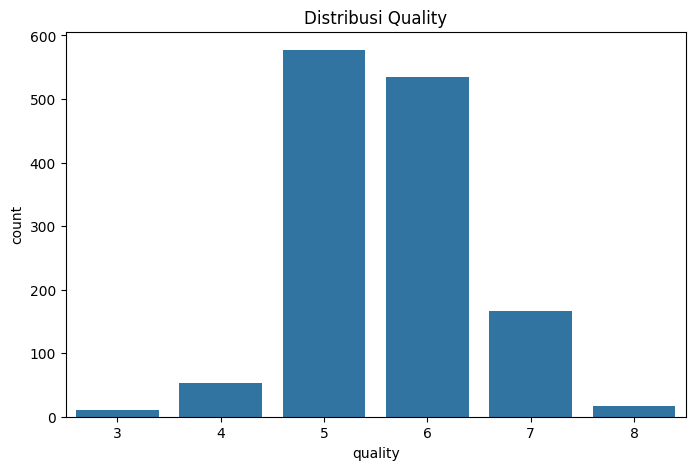

In [6]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='quality',
    data=df
)

plt.title("Distribusi Quality")
plt.show()

Menampilkan boxplot untuk setiap fitur kimia (kecuali quality). Digunakan untuk mendeteksi outlier secara visual — titik-titik di luar whisker adalah outlier.

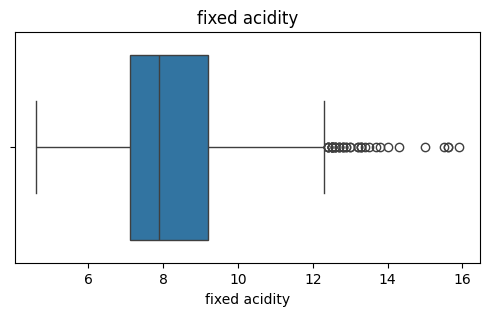

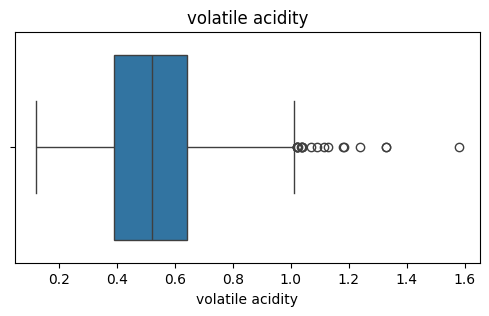

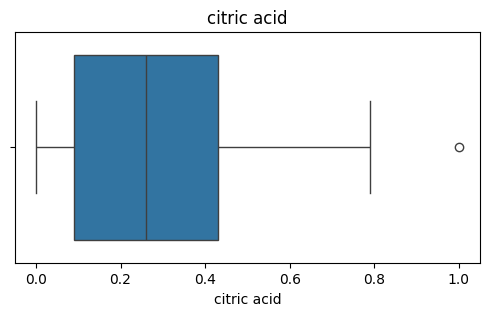

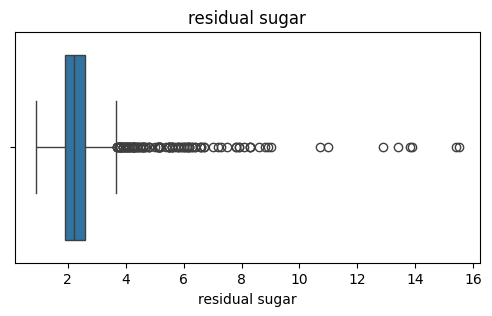

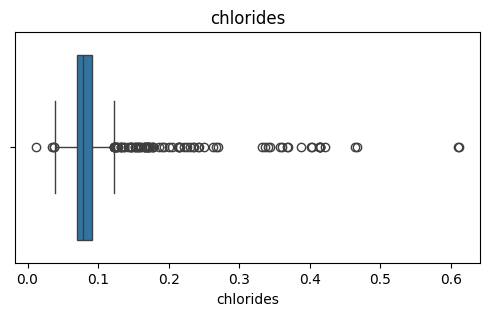

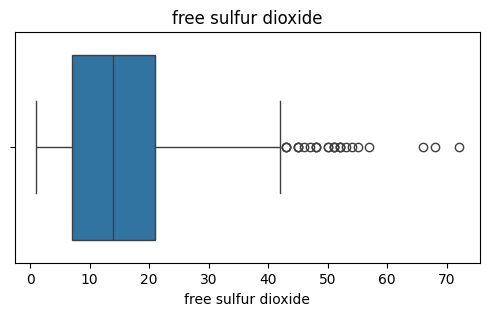

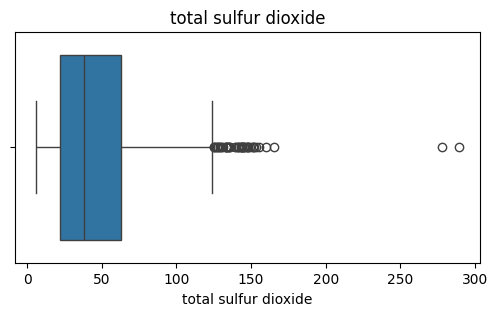

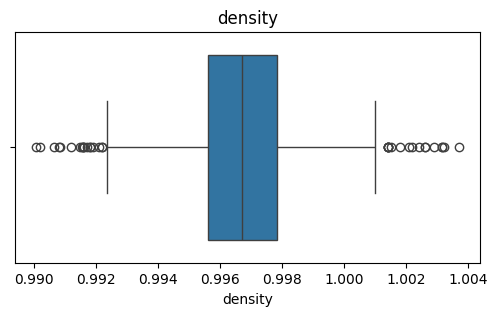

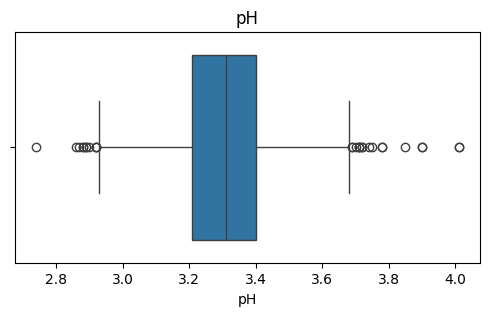

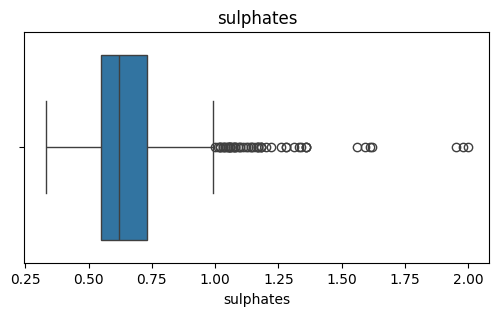

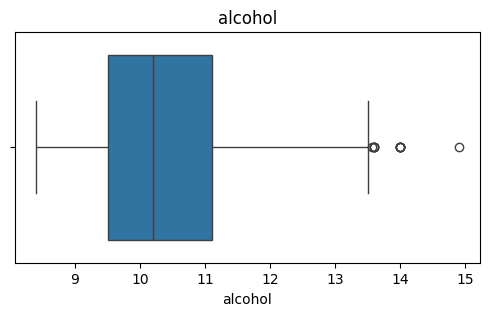

In [10]:
for col in df.columns:

    if col != 'quality':

        plt.figure(figsize=(6,3))

        sns.boxplot (
        x=df[col]
        )

        plt.title(col)

        plt. show

NameError: name 'df_sebelum' is not defined

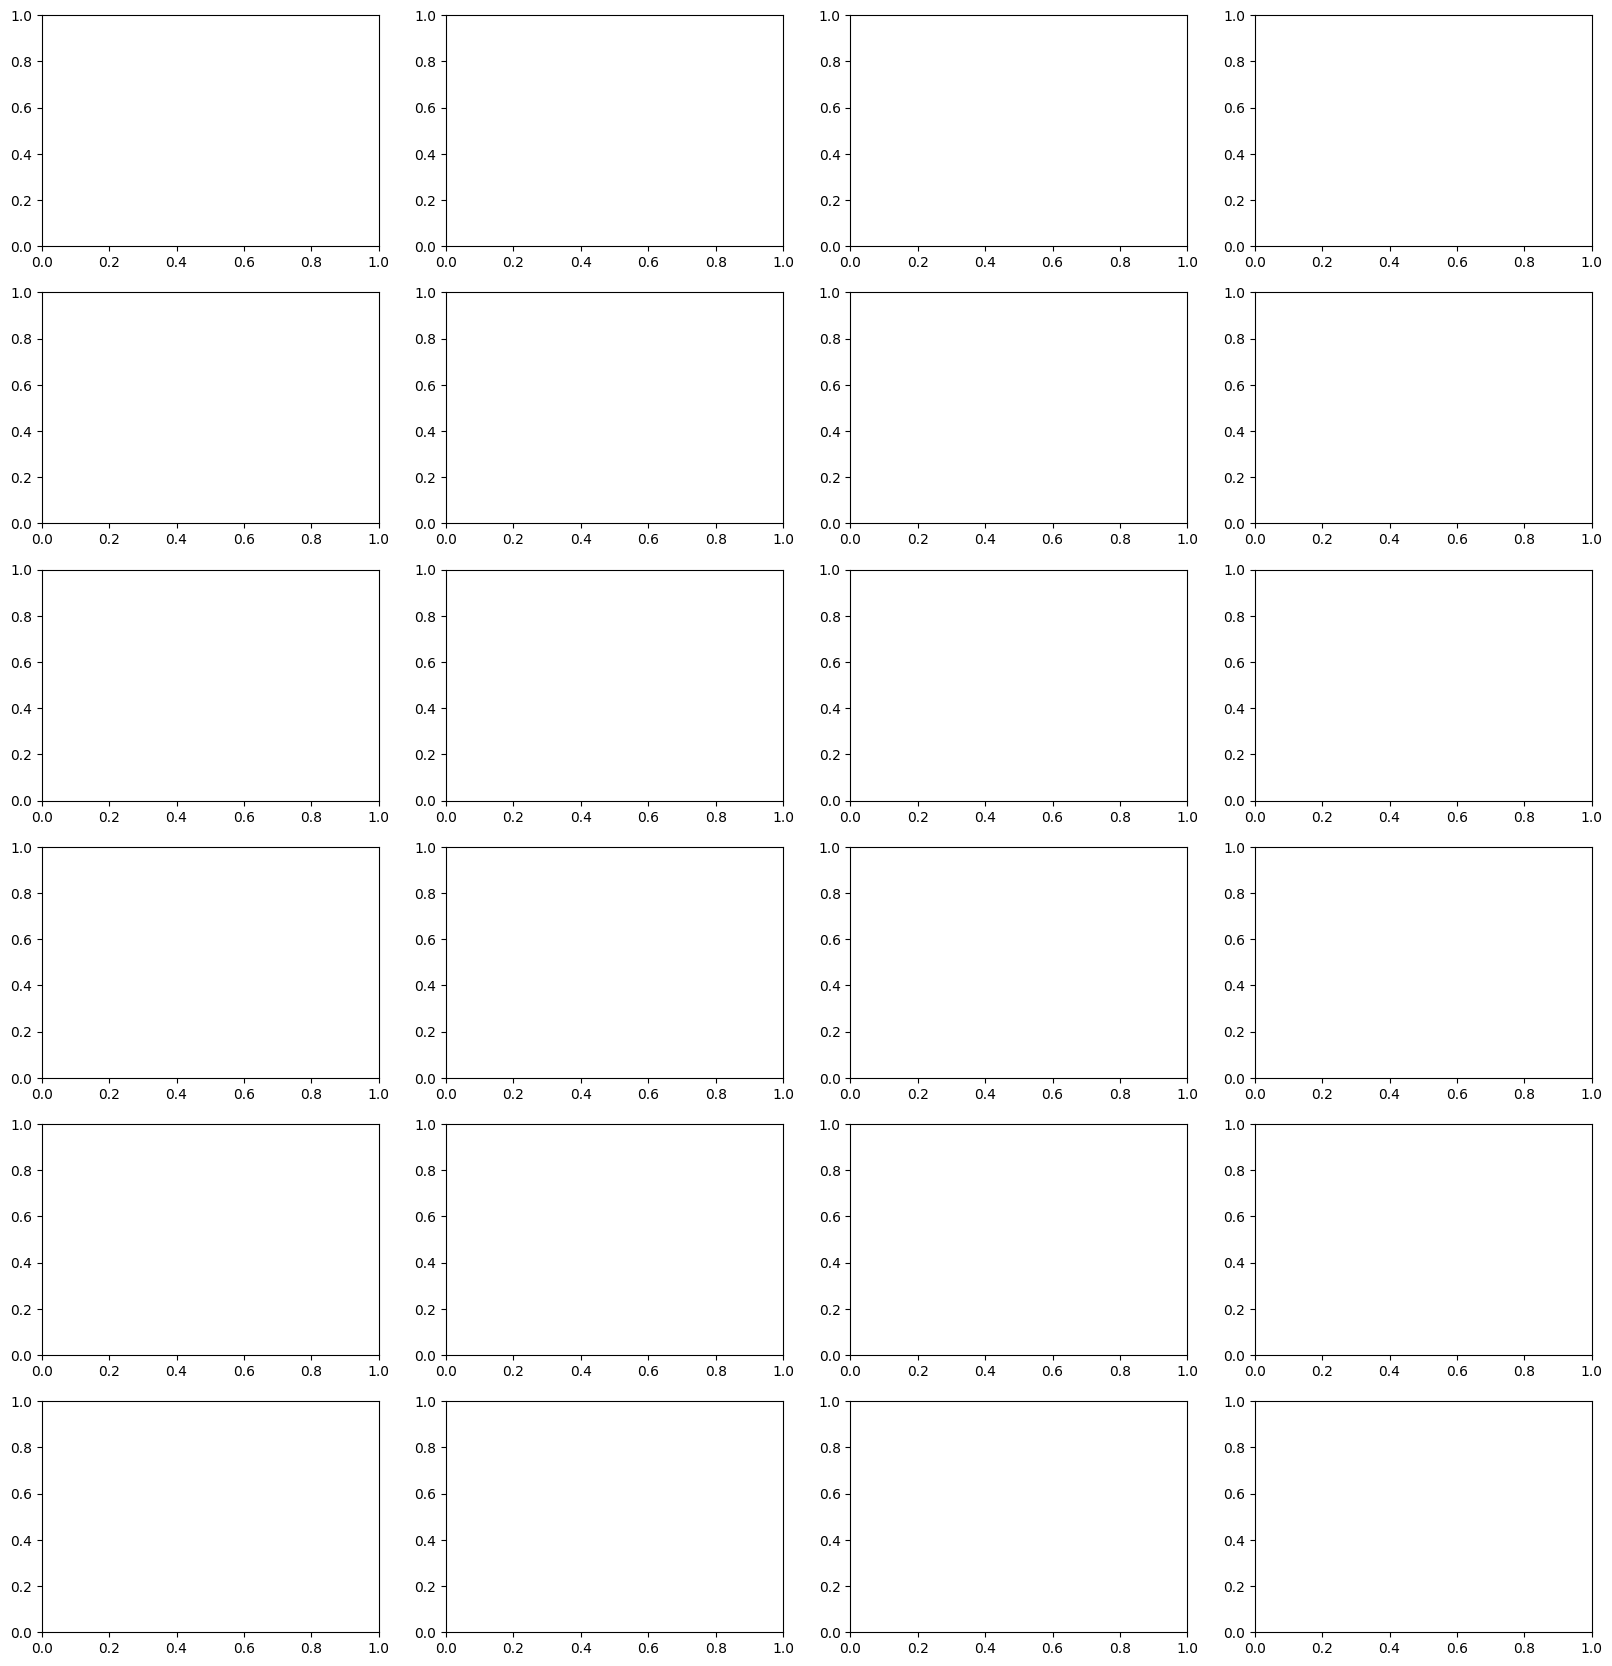

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 1. Daftarkan kolom-kolom numerik yang ingin kamu bandingkan
# Sesuaikan list ini dengan nama kolom asli di datasetmu
fitur_list = [
    'fixed acidity', 'free sulfur dioxide', 
    'volatile acidity', 'total sulfur dioxide',
    'citric acid', 'density', 
    'residual sugar', 'pH', 
    'chlorides', 'sulphates',
    'free sulfur dioxide_alt', 'alcohol' # Sesuaikan nama kolom terakhir jika berbeda
]

# 2. Hitung jumlah baris yang dibutuhkan (karena 1 baris memuat 2 pasang fitur = 4 kolom)
# Di gambar kamu ada 6 baris ke bawah
ncols = 4
nrows = 6

# Buat canvas subplots
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, nrows * 3.5))
axes = axes.flatten()

ax_idx = 0
for fitur in fitur_list:
    # --- Kolom A: Sebelum (Warna Merah/Salmon) ---
    if ax_idx < len(axes):
        # Ganti df_sebelum dengan nama dataframe awal kamu
        sns.boxplot(x=df_sebelum[fitur], ax=axes[ax_idx], color='#e77c73')
        axes[ax_idx].set_title(f"{fitur} (Sebelum)")
        axes[ax_idx].set_xlabel(fitur)
        ax_idx += 1
        
    # --- Kolom B: Setelah (Warna Hijau Muda) ---
    if ax_idx < len(axes):
        # Ganti df_sesudah dengan nama dataframe setelah diclip/IQR kamu
        sns.boxplot(x=df_sesudah[fitur], ax=axes[ax_idx], color='#8bda81')
        axes[ax_idx].set_title(f"{fitur} (Setelah Clip IQR)")
        axes[ax_idx].set_xlabel(fitur)
        ax_idx += 1

# 3. Bersihkan sisa kotak grid yang kosong jika ada
for j in range(ax_idx, len(axes)):
    fig.delaxes(axes[j])

# Mengatur jarak antar grafik supaya teksnya tidak tumpang tindih
plt.tight_layout()
plt.show()

Membuat matriks korelasi antar semua fitur. Angka mendekati +1 = korelasi positif kuat, mendekati -1 = negatif kuat. Berguna untuk melihat fitur mana yang paling berpengaruh terhadap quality

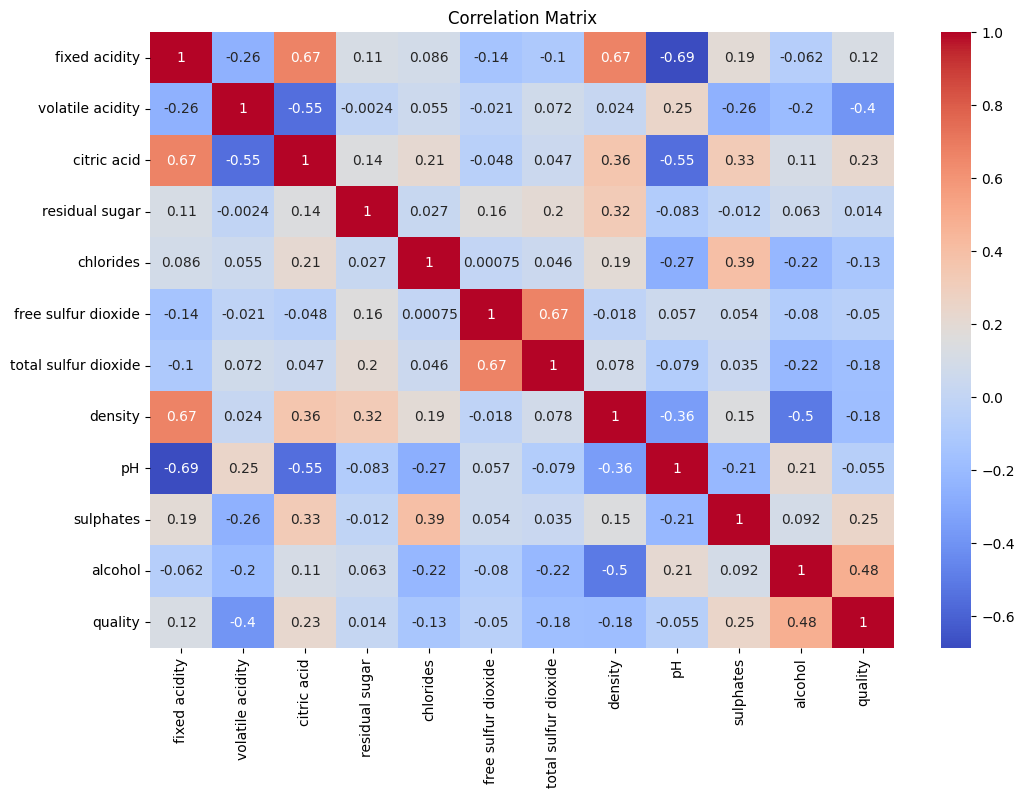

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

Menampilkan korelasi setiap fitur kimia terhadap kolom **quality** secara terurut. Ini melengkapi heatmap di atas dengan fokus langsung ke fitur mana yang paling berpengaruh terhadap kualitas wine, sehingga lebih mudah dibaca dibanding membaca seluruh matriks korelasi.

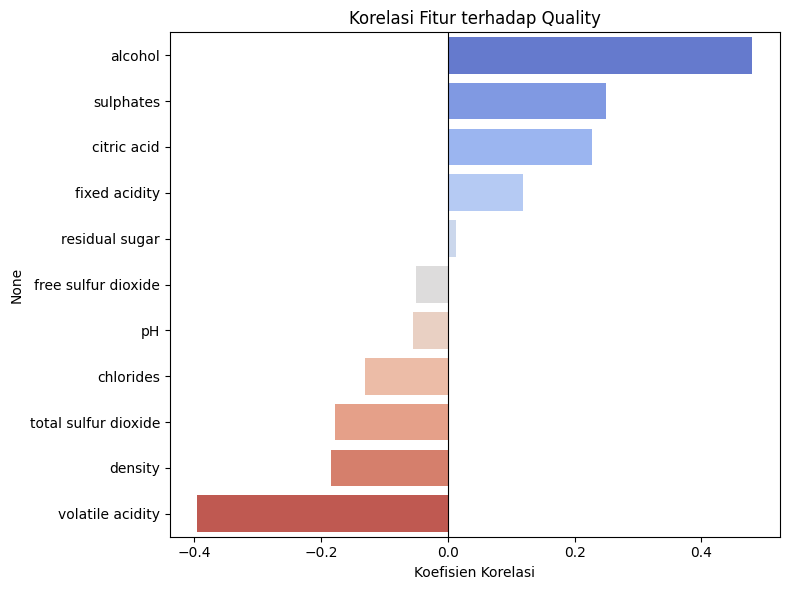

Ranking korelasi fitur terhadap quality:
alcohol                 0.480343
sulphates               0.248835
citric acid             0.228057
fixed acidity           0.119024
residual sugar          0.013640
free sulfur dioxide    -0.050463
pH                     -0.055245
chlorides              -0.130988
total sulfur dioxide   -0.177855
density                -0.184252
volatile acidity       -0.395214
Name: quality, dtype: float64


In [ ]:
corr_target = df.corr(numeric_only=True)['quality'].drop('quality').sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(
    x=corr_target.values,
    y=corr_target.index,
    hue=corr_target.index,
    palette='coolwarm',
    legend=False
)
plt.title("Korelasi Fitur terhadap Quality")
plt.xlabel("Koefisien Korelasi")
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print("Ranking korelasi fitur terhadap quality:")
print(corr_target)

Membuat direktori visualizations untuk menyimpan hasil plot.

In [ ]:
import os

VISUAL_DIR = 'visualizations'
if not os.path.exists(VISUAL_DIR):
    os.makedirs(VISUAL_DIR)

VISUAL = VISUAL_DIR

print(f"Direktori visualisasi '{VISUAL}' telah dibuat.")

Direktori visualisasi 'visualizations' telah dibuat.


## **DATA PREPARATION**

In [ ]:
print("--- MEMULAI PROSES DATA PREPARATION (11 FITUR) ---")

FEATURE_COLS = [
    'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
    'chlorides', 'free sulfur dioxide', 'total sulfur dioxide',
    'density', 'pH', 'sulphates', 'alcohol'
]

X_all = df[FEATURE_COLS].copy()
y = (df['quality'] > 5).astype(int)

print(f"Distribusi kelas target biner (0 = Bad, 1 = Good):\n{y.value_counts()}\n")

for col in FEATURE_COLS:
    Q1 = X_all[col].quantile(0.25)
    Q3 = X_all[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    X_all[col] = X_all[col].clip(lower_bound, upper_bound)
print("Outliers pada 11 fitur berhasil ditangani dengan metode Clip IQR.")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)
print("Standardisasi 11 fitur menggunakan StandardScaler selesai.")

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(f"Pembagian data selesai: Train set ({X_train.shape[0]} baris), Test set ({X_test.shape[0]} baris).")

--- MEMULAI PROSES DATA PREPARATION (11 FITUR) ---
Distribusi kelas target biner (0 = Bad, 1 = Good):
quality
1    719
0    640
Name: count, dtype: int64

Outliers pada 11 fitur berhasil ditangani dengan metode Clip IQR.
Standardisasi 11 fitur menggunakan StandardScaler selesai.
Pembagian data selesai: Train set (1087 baris), Test set (272 baris).


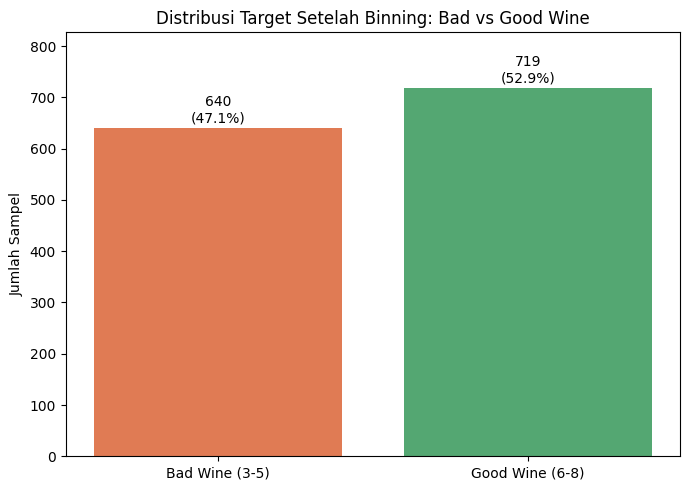

Distribusi setelah binning (Bad=0, Good=1):
quality
0    640
1    719
Name: count, dtype: int64

Proporsi -> Bad Wine: 47.1% | Good Wine: 52.9%


In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

label_counts = y.value_counts().sort_index()
label_names = ['Bad Wine (3-5)', 'Good Wine (6-8)']
bars = ax.bar(label_names, label_counts.values, color=['#E07B54', '#54A772'])
ax.set_title("Distribusi Target Setelah Binning: Bad vs Good Wine")
ax.set_ylabel("Jumlah Sampel")

total = label_counts.sum()
for bar, count in zip(bars, label_counts.values):
    persen = count / total * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f"{count}\n({persen:.1f}%)",
        ha='center', va='bottom'
    )
ax.set_ylim(0, label_counts.max() * 1.15)

plt.tight_layout()
plt.savefig(f"{VISUAL}/balance_after_binning.png", dpi=150)
plt.show()

print(f"Distribusi setelah binning (Bad=0, Good=1):\n{label_counts}")
print(f"\nProporsi -> Bad Wine: {label_counts[0]/total*100:.1f}% | Good Wine: {label_counts[1]/total*100:.1f}%")

Membandingkan distribusi fitur **sebelum** dan **sesudah** penanganan outlier (metode Clip IQR) menggunakan boxplot berdampingan. Hasil visualisasi disimpan ke folder `visualizations` yang sudah dibuat sebelumnya.

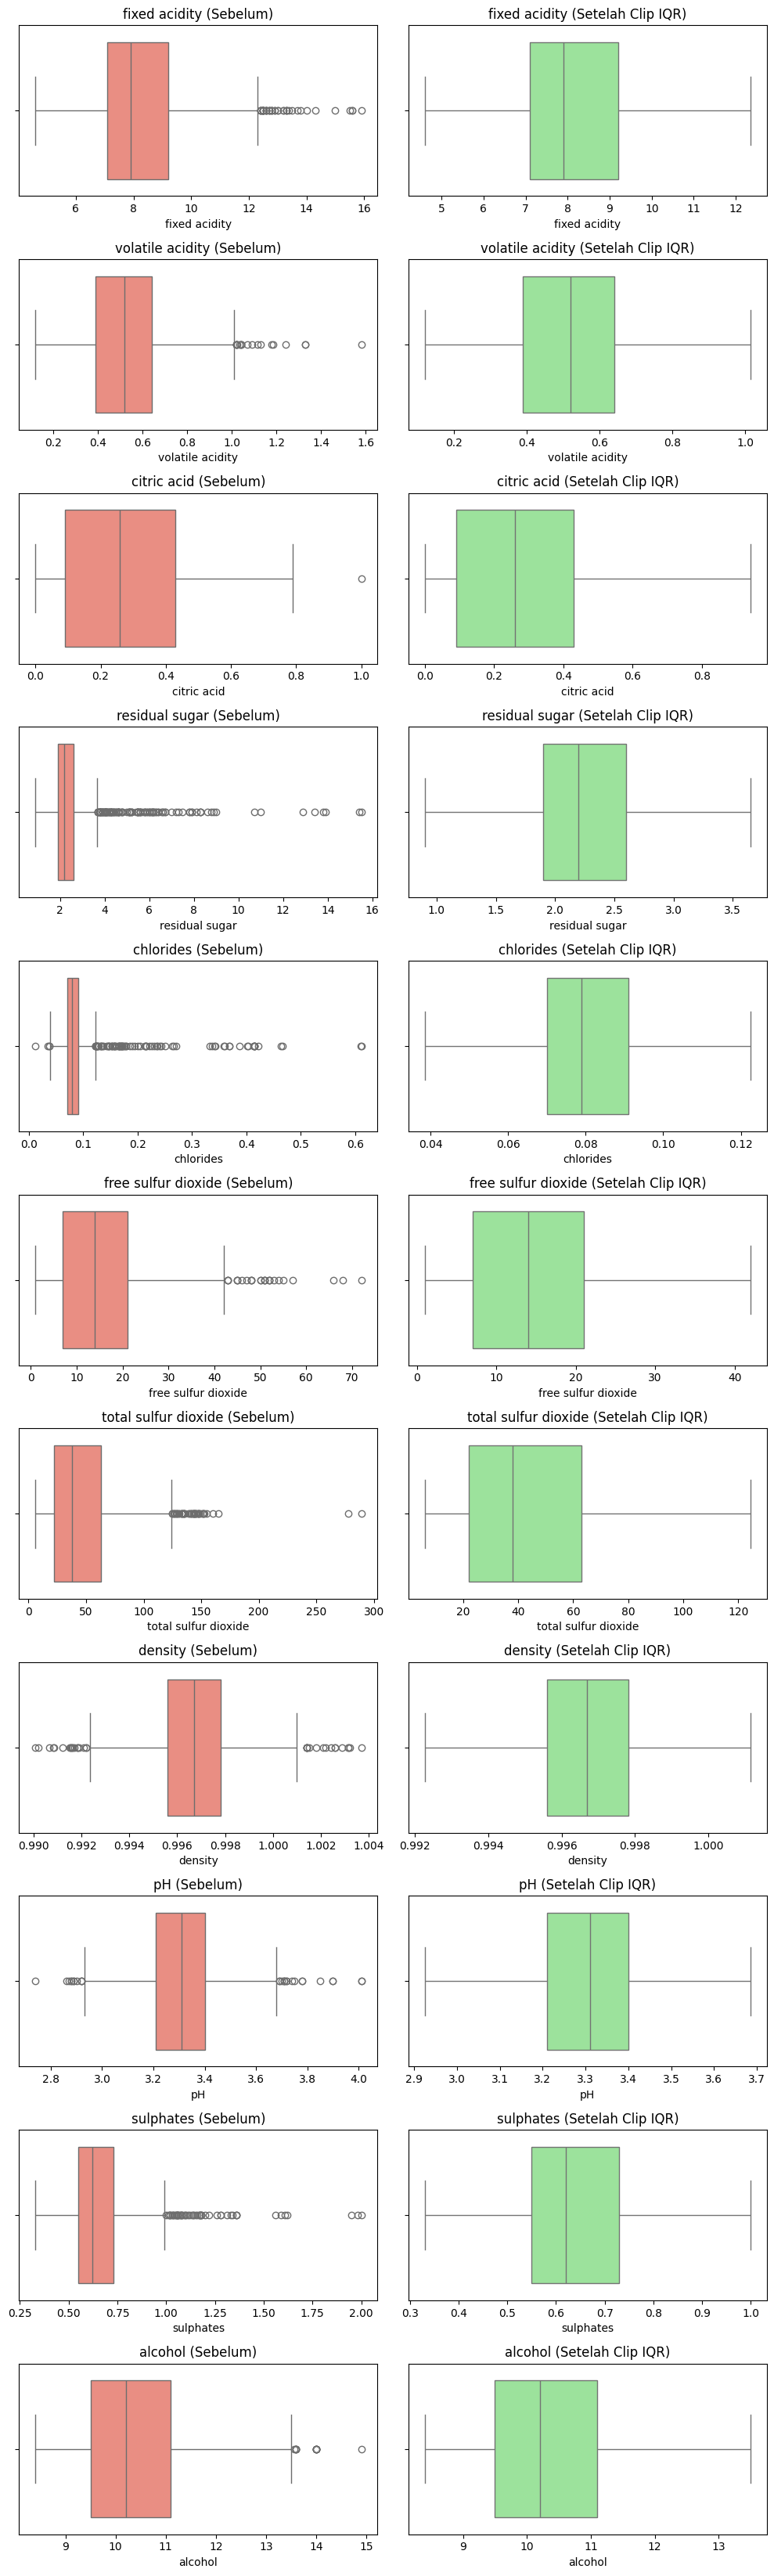

Visualisasi before-after outlier handling tersimpan di 'visualizations/outlier_before_after.png'


In [ ]:
X_before = df[FEATURE_COLS].copy()

fig, axes = plt.subplots(len(FEATURE_COLS), 2, figsize=(10, 3*len(FEATURE_COLS)))

for idx, col in enumerate(FEATURE_COLS):
    sns.boxplot(x=X_before[col], ax=axes[idx, 0], color='salmon')
    axes[idx, 0].set_title(f"{col} (Sebelum)")

    sns.boxplot(x=X_all[col], ax=axes[idx, 1], color='lightgreen')
    axes[idx, 1].set_title(f"{col} (Setelah Clip IQR)")

plt.tight_layout()
plt.savefig(f"{VISUAL}/outlier_before_after.png", dpi=150)
plt.show()

print(f"Visualisasi before-after outlier handling tersimpan di '{VISUAL}/outlier_before_after.png'")

## **MODELING**

Melatih tiga model:
- K-Means Clustering → mengelompokkan data ke 3 cluster (unsupervised), diinisialisasi dengan k-means++ agar lebih stabil
- Logistic Regression → model klasifikasi supervised berbasis regresi
- Gaussian Naïve Bayes → model klasifikasi probabilistik yang mengasumsikan fitur berdistribusi normal

Sebelum menetapkan jumlah cluster K-Means, dilakukan pencarian **k optimal** menggunakan kombinasi **Elbow Method** (melihat penurunan inertia) dan **Silhouette Score** untuk beberapa nilai k (2 sampai 8) pada data latih.

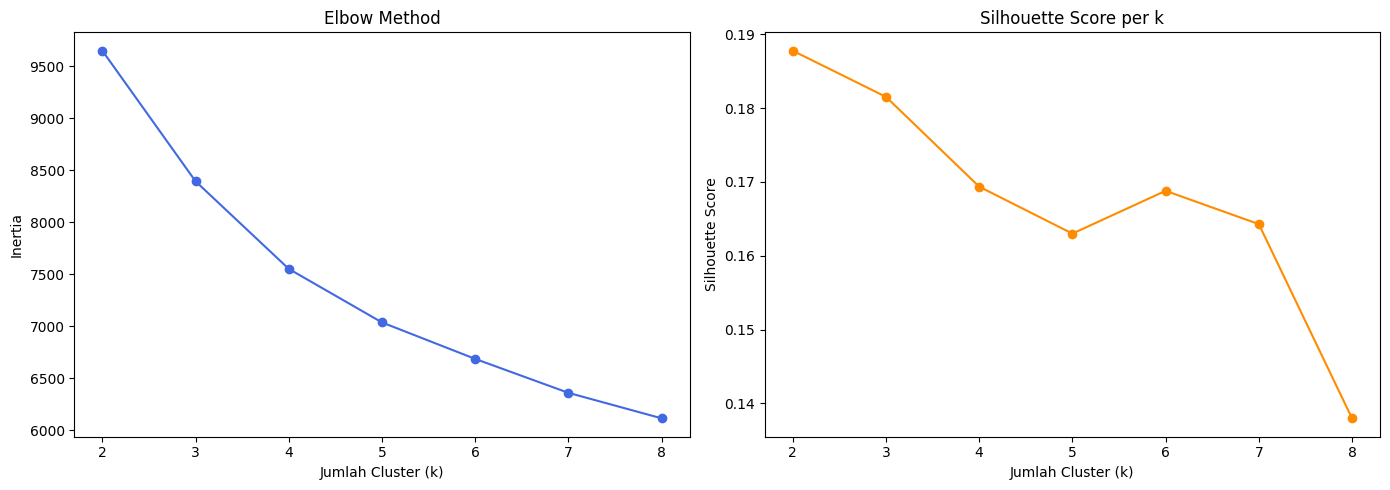

Silhouette Score per k:
  k=2: silhouette=0.1878
  k=3: silhouette=0.1815
  k=4: silhouette=0.1694
  k=5: silhouette=0.1630
  k=6: silhouette=0.1688
  k=7: silhouette=0.1643
  k=8: silhouette=0.1380

k dengan Silhouette Score tertinggi: 2


In [ ]:
inertia_list = []
silhouette_list = []
k_range = range(2, 9)

for k in k_range:
    km_temp = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels_temp = km_temp.fit_predict(X_train)
    inertia_list.append(km_temp.inertia_)
    silhouette_list.append(silhouette_score(X_train, labels_temp))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertia_list, marker='o', color='royalblue')
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Jumlah Cluster (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), silhouette_list, marker='o', color='darkorange')
axes[1].set_title("Silhouette Score per k")
axes[1].set_xlabel("Jumlah Cluster (k)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.savefig(f"{VISUAL}/elbow_silhouette.png", dpi=150)
plt.show()

best_k = list(k_range)[int(np.argmax(silhouette_list))]
print("Silhouette Score per k:")
for k_val, sil_val in zip(k_range, silhouette_list):
    print(f"  k={k_val}: silhouette={sil_val:.4f}")
print(f"\nk dengan Silhouette Score tertinggi: {best_k}")

In [ ]:
kmeans_model = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
train_cluster_labels = kmeans_model.fit_predict(X_train)
test_cluster_labels = kmeans_model.predict(X_test)
print("Pemodelan K-Means Clustering dengan 11 Fitur sukses dilakukan.")

lr_model = LogisticRegression(random_state=42)
nb_model = GaussianNB()

lr_model.fit(X_train, y_train)
nb_model.fit(X_train, y_train)
print("Model Logistic Regression & Gaussian Naïve Bayes sukses dilatih.")

Pemodelan K-Means Clustering dengan 11 Fitur sukses dilakukan.
Model Logistic Regression & Gaussian Naïve Bayes sukses dilatih.


Memvisualisasikan hasil K-Means Clustering dalam ruang 2 dimensi menggunakan **PCA (Principal Component Analysis)** untuk mereduksi 11 fitur menjadi 2 komponen utama, sehingga sebaran cluster bisa diamati secara visual.

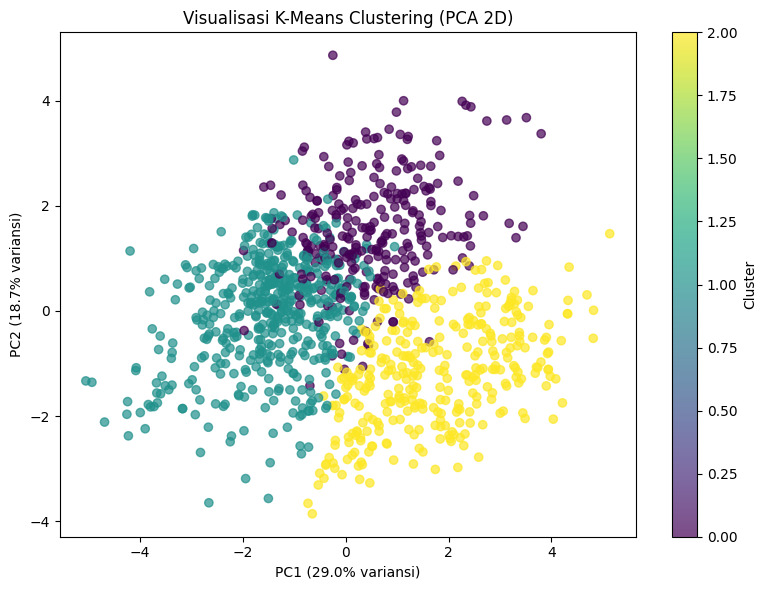

Total variansi yang dijelaskan oleh 2 komponen PCA: 47.71%


In [ ]:
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train)

plt.figure(figsize=(8,6))
scatter = plt.scatter(
    X_train_pca[:, 0], X_train_pca[:, 1],
    c=train_cluster_labels, cmap='viridis', alpha=0.7
)
plt.title("Visualisasi K-Means Clustering (PCA 2D)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variansi)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variansi)")
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.savefig(f"{VISUAL}/kmeans_pca_clusters.png", dpi=150)
plt.show()

print(f"Total variansi yang dijelaskan oleh 2 komponen PCA: "
      f"{sum(pca.explained_variance_ratio_)*100:.2f}%")

## **EVALUATION**

Mengevaluasi ketiga model yang telah dilatih:
- K-Means → dievaluasi dengan Silhouette Score (mendekati 1 = cluster bagus)
- Logistic Regression & Naïve Bayes → dievaluasi dengan akurasi, precision, recall, F1-score, dan confusion matrix
- Confusion matrix dipecah manual: True Positive, True Negative, False Positive, False Negative

In [ ]:
print("--- MEMULAI PROSES EVALUASI MODEL ---\n")

sil_score = silhouette_score(X_test, test_cluster_labels)
print(f"[K-Means] Silhouette Score pada data uji: {sil_score:.4f}")
print("-" * 60)

y_pred_lr = lr_model.predict(X_test)
y_pred_nb = nb_model.predict(X_test)

print(f"[Akurasi] Logistic Regression  : {accuracy_score(y_test, y_pred_lr)*100:.2f}%")
print(f"[Akurasi] Gaussian Naïve Bayes : {accuracy_score(y_test, y_pred_nb)*100:.2f}%")
print("-" * 60)

print("\n LAPORAN KLASIFIKASI DETAIL - LOGISTIC REGRESSION:")
print(classification_report(y_test, y_pred_lr, target_names=['Bad Wine', 'Good Wine']))

print("\n LAPORAN KLASIFIKASI DETAIL - GAUSSIAN NAÏVE BAYES:")
print(classification_report(y_test, y_pred_nb, target_names=['Bad Wine', 'Good Wine']))

cm_lr = confusion_matrix(y_test, y_pred_lr)
print("\nCONFUSION MATRIX (Logistic Regression):")
print(f"True Negative (Tebakan Bad benar) : {cm_lr[0][0]}")
print(f"False Positive (Salah tebak Good) : {cm_lr[0][1]}")
print(f"False Negative (Salah tebak Bad)  : {cm_lr[1][0]}")
print(f"True Positive (Tebakan Good benar): {cm_lr[1][1]}")

--- MEMULAI PROSES EVALUASI MODEL ---

[K-Means] Silhouette Score pada data uji: 0.1548
------------------------------------------------------------
[Akurasi] Logistic Regression  : 72.06%
[Akurasi] Gaussian Naïve Bayes : 73.90%
------------------------------------------------------------

 LAPORAN KLASIFIKASI DETAIL - LOGISTIC REGRESSION:
              precision    recall  f1-score   support

    Bad Wine       0.69      0.73      0.71       128
   Good Wine       0.75      0.72      0.73       144

    accuracy                           0.72       272
   macro avg       0.72      0.72      0.72       272
weighted avg       0.72      0.72      0.72       272


 LAPORAN KLASIFIKASI DETAIL - GAUSSIAN NAÏVE BAYES:
              precision    recall  f1-score   support

    Bad Wine       0.70      0.77      0.74       128
   Good Wine       0.78      0.71      0.74       144

    accuracy                           0.74       272
   macro avg       0.74      0.74      0.74       272
weight

In [ ]:
cm_nb = confusion_matrix(y_test, y_pred_nb)
print("CONFUSION MATRIX (Gaussian Naïve Bayes):")
print(f"True Negative (Tebakan Bad benar) : {cm_nb[0][0]}")
print(f"False Positive (Salah tebak Good) : {cm_nb[0][1]}")
print(f"False Negative (Salah tebak Bad)  : {cm_nb[1][0]}")
print(f"True Positive (Tebakan Good benar): {cm_nb[1][1]}")

CONFUSION MATRIX (Gaussian Naïve Bayes):
True Negative (Tebakan Bad benar) : 99
False Positive (Salah tebak Good) : 29
False Negative (Salah tebak Bad)  : 42
True Positive (Tebakan Good benar): 102


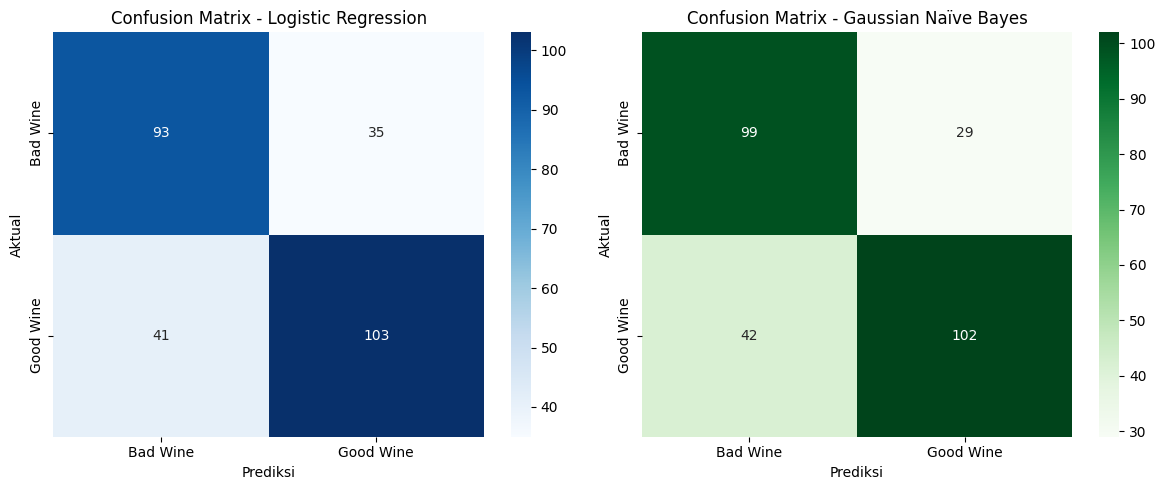

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    cm_lr, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Bad Wine', 'Good Wine'],
    yticklabels=['Bad Wine', 'Good Wine'],
    ax=axes[0]
)
axes[0].set_title("Confusion Matrix - Logistic Regression")
axes[0].set_xlabel("Prediksi")
axes[0].set_ylabel("Aktual")

sns.heatmap(
    cm_nb, annot=True, fmt='d', cmap='Greens',
    xticklabels=['Bad Wine', 'Good Wine'],
    yticklabels=['Bad Wine', 'Good Wine'],
    ax=axes[1]
)
axes[1].set_title("Confusion Matrix - Gaussian Naïve Bayes")
axes[1].set_xlabel("Prediksi")
axes[1].set_ylabel("Aktual")

plt.tight_layout()
plt.savefig(f"{VISUAL}/confusion_matrices.png", dpi=150)
plt.show()

Tabel Perbandingan Metrik:


,Logistic Regression,Gaussian Naive Bayes
Accuracy,0.720588,0.738971
Precision,0.746377,0.778626
Recall,0.715278,0.708333
F1-Score,0.730496,0.741818


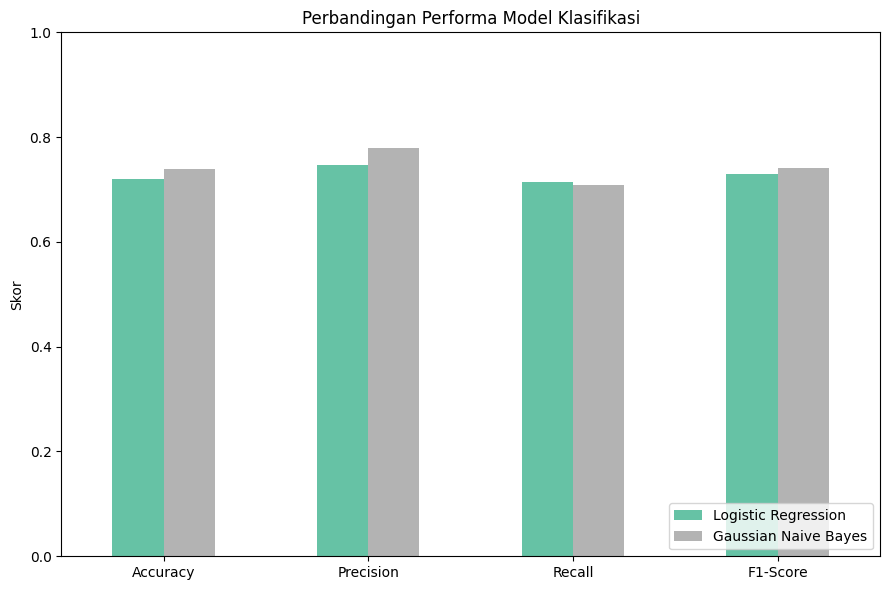

In [ ]:
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_nb = accuracy_score(y_test, y_pred_nb)
prec_lr = precision_score(y_test, y_pred_lr)
prec_nb = precision_score(y_test, y_pred_nb)
rec_lr = recall_score(y_test, y_pred_lr)
rec_nb = recall_score(y_test, y_pred_nb)
f1_lr = f1_score(y_test, y_pred_lr)
f1_nb = f1_score(y_test, y_pred_nb)

comparison_df = pd.DataFrame({
    'Logistic Regression': [acc_lr, prec_lr, rec_lr, f1_lr],
    'Gaussian Naive Bayes': [acc_nb, prec_nb, rec_nb, f1_nb]
}, index=['Accuracy', 'Precision', 'Recall', 'F1-Score'])

print("Tabel Perbandingan Metrik:")
display(comparison_df)

comparison_df.plot(kind='bar', figsize=(9,6), colormap='Set2')
plt.title("Perbandingan Performa Model Klasifikasi")
plt.ylabel("Skor")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f"{VISUAL}/model_comparison.png", dpi=150)
plt.show()

Crosstab Cluster K-Means vs Label Quality Asli:


quality_label,Bad Wine,Good Wine
cluster,,
0,46,23
1,55,61
2,27,60


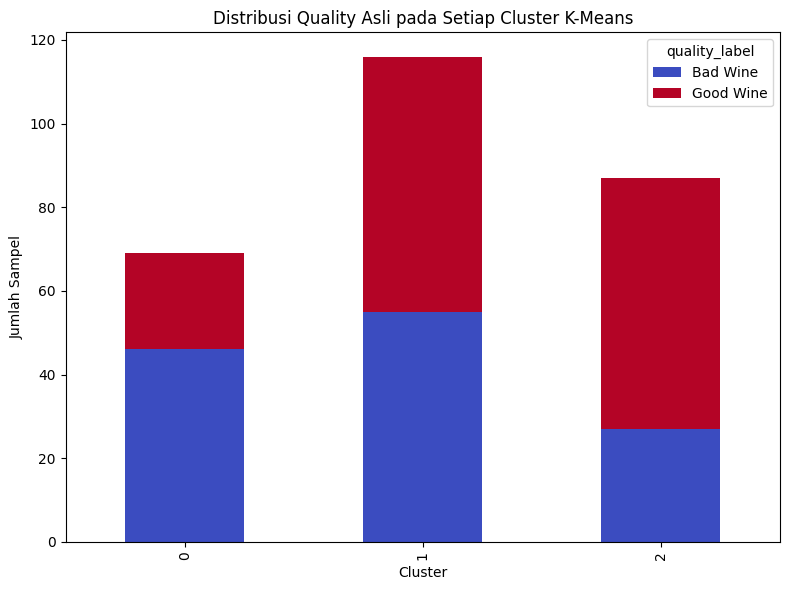

In [ ]:
cluster_quality_df = pd.DataFrame({
    'cluster': test_cluster_labels,
    'quality_label': y_test.map({0: 'Bad Wine', 1: 'Good Wine'}).values
})

crosstab_result = pd.crosstab(
    cluster_quality_df['cluster'],
    cluster_quality_df['quality_label']
)

print("Crosstab Cluster K-Means vs Label Quality Asli:")
display(crosstab_result)

crosstab_result.plot(kind='bar', stacked=True, figsize=(8,6), colormap='coolwarm')
plt.title("Distribusi Quality Asli pada Setiap Cluster K-Means")
plt.xlabel("Cluster")
plt.ylabel("Jumlah Sampel")
plt.tight_layout()
plt.savefig(f"{VISUAL}/cluster_vs_quality.png", dpi=150)
plt.show()

## **DEPLOYMENT PREPARATION**

Menyimpan semua model dan scaler ke format .pkl (pickle) menggunakan joblib. File ini nantinya bisa di-load ulang untuk prediksi tanpa perlu training ulang

In [ ]:
import joblib

joblib.dump(scaler, 'scaler.pkl')
joblib.dump(lr_model, 'lr_model.pkl')
joblib.dump(nb_model, 'nb_model.pkl')
joblib.dump(kmeans_model, 'kmeans_model.pkl')
joblib.dump(FEATURE_COLS, 'feature_cols.pkl')

print("PROSES BERHASIL UTUH DENGAN 11 FITUR KIMIA")
print(f"Daftar {len(FEATURE_COLS)} nama fitur berhasil disimpan ke 'feature_cols.pkl'.")

PROSES BERHASIL UTUH DENGAN 11 FITUR KIMIA
Daftar 11 nama fitur berhasil disimpan ke 'feature_cols.pkl'.
